# LangGraph Portfolio

A progression from a minimal single-node graph to a stateful, memory-aware conversational agent — built with [LangGraph](https://github.com/langchain-ai/langgraph) and LangChain.

---

## Setup

Extensions and imports used throughout the notebook.
- **`dotenv`** — loads the OpenAI API key from a `.env` file, keeping credentials out of source code.
- **`InMemorySaver`** — LangGraph checkpointer that persists thread state in memory for the lifetime of the process.
- **`SqliteSaver`** — LangGraph checkpointer that persists thread state to a SQLite database across process restarts.

In [1]:
%load_ext dotenv
%dotenv

from langgraph.graph import START, END, StateGraph, add_messages, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, BaseMessage, RemoveMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from typing import Literal, Annotated
import sqlite3

chat = ChatOpenAI(model="gpt-4o", seed=365, temperature=0, max_completion_tokens=100)


C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


---
## 1 · Simple Graph: `START → chatbot → END`

The simplest possible LangGraph program — a single node that receives a message, calls an LLM, and returns the response.

### State

`State` is the **shared memory** of the graph — a `TypedDict` that every node reads from and writes to.
`Sequence[BaseMessage]` lets the list hold any mix of `HumanMessage`, `AIMessage`, and `SystemMessage` objects.

### Nodes

Each node is a plain Python function: it receives the current `State`, does work, and returns an updated `State`.
The `chatbot` node sends the full message list to the LLM and returns the response.

### Graph

`StateGraph` is a **blueprint** — add nodes and edges, then call `.compile()` to get a runnable object.
The uncompiled `graph` is *not* a `Runnable`; `graph_compiled` is.

================================ Human Message =================================

Could you tell me a grook by Piet Hein?
Is Runnable before compile? False


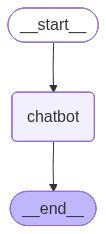

In [2]:
class State1(TypedDict):
    messages: Sequence[BaseMessage]

initial_state = State1(messages=[HumanMessage("Could you tell me a grook by Piet Hein?")])
initial_state["messages"][0].pretty_print()

def chatbot(state: State1) -> State1:
    print(f"\n-------> ENTERING chatbot:")
    response = chat.invoke(state["messages"])
    response.pretty_print()
    return State1(messages=[response])

graph = StateGraph(State1)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

graph_compiled = graph.compile()
print("Is Runnable before compile?", isinstance(graph, Runnable))
graph_compiled

### Test

In [3]:
graph_compiled.invoke(initial_state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

Certainly! Here is one of Piet Hein's well-known grooks:

```
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are short, witty poems that often contain philosophical insights or reflections on everyday life.


{'messages': [AIMessage(content="Certainly! Here is one of Piet Hein's well-known grooks:\n\n```\nLosing One Glove\n\nLosing one glove\nis certainly painful,\nbut nothing\ncompared to the pain\nof losing one,\nthrowing away the other,\nand finding\nthe first one again.\n```\n\nPiet Hein's grooks are short, witty poems that often contain philosophical insights or reflections on everyday life.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 18, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_246dab3317', 'id': 'chatcmpl-Dg2vPoaqhJeF0KNsjLYJG4QcmB6dW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2f80-2fba-7e62-93b8-4

---
## 2 · Conditional Edges: Interactive Q&A Loop

A fixed linear graph can only do one thing. **Conditional edges** let the graph branch based on state — enabling loops, retries, and dynamic routing.

This graph lets the user ask multiple questions, looping back until they choose to stop.

### Nodes

### Routing Function

A routing function is a plain Python function that reads `state` and returns the **name of the next node** as a string.
It is passed to `add_conditional_edges` — never registered as a node itself.

### Graph

Two kinds of edges:
- **Fixed** (`add_edge`) — the path is always the same.
- **Conditional** (`add_conditional_edges`) — LangGraph calls the routing function after `ask_another_question` and follows whatever node name it returns.

Topology: `START → ask_question → chatbot → ask_another_question →(yes)→ ask_question` / `→(no)→ END`

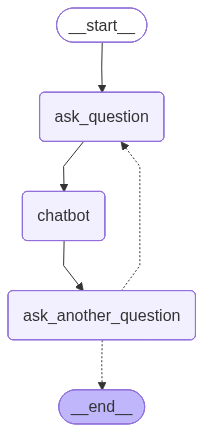

In [4]:
def ask_question(state: State1) -> State1:
    print(f"\n-------> ENTERING ask_question:")
    print("What is your question?")
    return State1(messages=[HumanMessage(input())])

def ask_another_question(state: State1) -> State1:
    print(f"\n-------> ENTERING ask_another_question:")
    print("Would you like to ask one more question (yes/no)?")
    return State1(messages=[HumanMessage(input())])

def routing_function(state: State1) -> Literal["ask_question", "__end__"]:
    return "ask_question" if state["messages"][-1].content == "yes" else "__end__"

graph2 = StateGraph(State1)
graph2.add_node("ask_question", ask_question)
graph2.add_node("chatbot", chatbot)
graph2.add_node("ask_another_question", ask_another_question)
graph2.add_edge(START, "ask_question")
graph2.add_edge("ask_question", "chatbot")
graph2.add_edge("chatbot", "ask_another_question")
graph2.add_conditional_edges("ask_another_question", routing_function)

graph2_compiled = graph2.compile()
graph2_compiled

### Test

In [5]:
graph2_compiled.invoke(State1(messages=[]))


-------> ENTERING ask_question:
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 yes



-------> ENTERING ask_question:
What is your question?


 Name a few cities in the country



-------> ENTERING chatbot:
================================== Ai Message ==================================

Certainly! However, I need to know which country you are referring to in order to provide a list of cities. Could you please specify the country?

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 no


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}

---
## 3 · Reducer Functions: Persistent Conversation Memory

In the previous two sections, returning `State(messages=[...])` **replaced** the entire list each turn — the graph had no memory.

**Reducer functions** define *how* a key is updated rather than just overwriting it.
`add_messages` is LangGraph's built-in reducer: it **appends** incoming messages to the existing list, preserving full conversation history across loop iterations.

Attaching it to the `messages` field via `Annotated` is all that's needed.

### Exploring `add_messages`

`add_messages(existing, new)` merges two message lists — appending new ones and deduplicating by `id` if a message already exists.

In [6]:
existing: Sequence[BaseMessage] = [HumanMessage("Hi! I'm Oscar."), AIMessage("Hey, Oscar. How can I assist you?")]
new_msgs: Sequence[BaseMessage] = [HumanMessage("Could you summarize today's news?")]
my_list = add_messages(existing, new_msgs)
my_list

[HumanMessage(content="Hi! I'm Oscar.", additional_kwargs={}, response_metadata={}, id='62b1b0cb-3ec4-411a-a9e4-2f6d2701433a'),
 AIMessage(content='Hey, Oscar. How can I assist you?', additional_kwargs={}, response_metadata={}, id='274b0ed9-cb48-4659-bf93-7a99eba81815', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="Could you summarize today's news?", additional_kwargs={}, response_metadata={}, id='77c72b5d-02d3-424e-8ba5-108febda5ccf')]

### Annotated State

Swapping `Sequence[BaseMessage]` for `Annotated[Sequence[BaseMessage], add_messages]` is the only change to `State`.
LangGraph detects the annotation and calls `add_messages` automatically whenever a node returns new messages.

### Nodes

The nodes are extended to print the full message history on entry — demonstrating that memory is now preserved across turns.
`ask_question` and `ask_another_question` also store the prompt text itself as an `AIMessage` so it appears in history.

### Graph

Same topology as Section 2 — the only structural change is the `State` definition above.
The reducer does its work silently in the background.

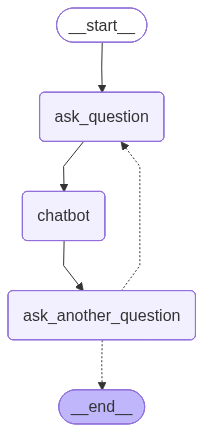

In [7]:
class State3(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

def ask_question(state: State3) -> State3:
    print(f"\n-------> ENTERING ask_question:")
    for msg in state["messages"]:
        msg.pretty_print()
    question = "What is your question?"
    print(question)
    return State3(messages=[AIMessage(question), HumanMessage(input())])

def chatbot(state: State3) -> State3:
    print(f"\n-------> ENTERING chatbot:")
    for msg in state["messages"]:
        msg.pretty_print()
    response = chat.invoke(state["messages"])
    response.pretty_print()
    return State3(messages=[response])

def ask_another_question(state: State3) -> State3:
    print(f"\n-------> ENTERING ask_another_question:")
    for msg in state["messages"]:
        msg.pretty_print()
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    return State3(messages=[AIMessage(question), HumanMessage(input())])

def routing_function(state: State3) -> Literal["ask_question", "__end__"]:
    return "ask_question" if state["messages"][-1].content == "yes" else "__end__"

graph3 = StateGraph(State3)
graph3.add_node("ask_question", ask_question)
graph3.add_node("chatbot", chatbot)
graph3.add_node("ask_another_question", ask_another_question)
graph3.add_edge(START, "ask_question")
graph3.add_edge("ask_question", "chatbot")
graph3.add_edge("chatbot", "ask_another_question")
graph3.add_conditional_edges(source="ask_another_question", path=routing_function)

graph3_compiled = graph3.compile()
graph3_compiled

### Test

In [8]:
graph3_compiled.invoke(State3(messages=[]))


-------> ENTERING ask_question:
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests

-------> ENTERING ask_another_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =====

 yes



-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message ==============

 Name a few cities in the country



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message ===================

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='68481334-69c6-47ed-ba56-55a14e9db5d6', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Describe the Philippines', additional_kwargs={}, response_metadata={}, id='674e198d-a5e6-4bd4-9aaf-ce1fb5f1d2f1'),
  AIMessage(content='The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.\n\n**Geography and Climate:**\nThe Philippines has a diverse range of landscapes, including mountains, rainforests', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 19, 'total_tokens': 119, 'completion_tokens_details': {'

---
## 4 · `MessagesState`: Built-in Convenience Class

In Section 3, we manually defined:

```python
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
```

`MessagesState` is LangGraph's pre-built equivalent — it ships with that exact field already wired up. Using it eliminates the boilerplate entirely while keeping the same behaviour: messages are appended, never overwritten.

It also serves as a convenient **base class** when your graph needs additional state fields beyond `messages` — just subclass it and add your own keys.

### Nodes

The nodes are identical to Section 3 in logic — the only change is the type annotations: `State` → `MessagesState`. No `Annotated`, no `TypedDict`, no manual reducer attachment.

### Graph

`StateGraph(MessagesState)` replaces `StateGraph(State)`. Everything else — nodes, edges, routing — is unchanged. This is the idiomatic way to build message-passing graphs in LangGraph.

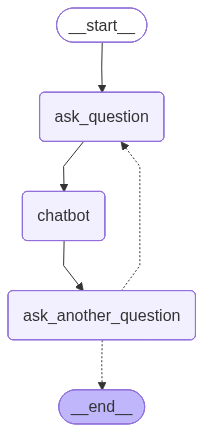

In [9]:
def ask_question(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING ask_question:")
    for msg in state["messages"]:
        msg.pretty_print()
    question = "What is your question?"
    print(question)
    return MessagesState(messages=[AIMessage(question), HumanMessage(input())])

def chatbot(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING chatbot:")
    for msg in state["messages"]:
        msg.pretty_print()
    response = chat.invoke(state["messages"])
    response.pretty_print()
    return MessagesState(messages=[response])

def ask_another_question(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING ask_another_question:")
    for msg in state["messages"]:
        msg.pretty_print()
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    return MessagesState(messages=[AIMessage(question), HumanMessage(input())])

def routing_function(state: MessagesState) -> Literal["ask_question", "__end__"]:
    return "ask_question" if state["messages"][-1].content == "yes" else "__end__"

graph4 = StateGraph(MessagesState)
graph4.add_node("ask_question", ask_question)
graph4.add_node("chatbot", chatbot)
graph4.add_node("ask_another_question", ask_another_question)
graph4.add_edge(START, "ask_question")
graph4.add_edge("ask_question", "chatbot")
graph4.add_edge("chatbot", "ask_another_question")
graph4.add_conditional_edges(source="ask_another_question", path=routing_function)

graph4_compiled = graph4.compile()
graph4_compiled

### Test

In [10]:
graph4_compiled.invoke(MessagesState(messages=[]))


-------> ENTERING ask_question:
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests

-------> ENTERING ask_another_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =====

 yes



-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message ==============

 Name a few islands in the country



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message ===================

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='4138206b-f28d-47b4-b3cf-40500b2f44f9', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Describe the Philippines', additional_kwargs={}, response_metadata={}, id='428a7ffc-c558-4c1d-aa73-979494c8c886'),
  AIMessage(content='The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.\n\n**Geography and Climate:**\nThe Philippines has a diverse range of landscapes, including mountains, rainforests', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 19, 'total_tokens': 119, 'completion_tokens_details': {'

---
## 5 · `RemoveMessage`: Selective Memory Pruning

`add_messages` appends forever — useful, but real applications need to manage context window size. `RemoveMessage` is a special sentinel: pass a list of `RemoveMessage(id=...)` objects to `add_messages` and it will **delete** every message whose `id` matches, leaving the rest intact.

This makes targeted pruning straightforward: slice the history, build the removal list, apply it — all without replacing or rebuilding state from scratch.

### Exploring `RemoveMessage`

A concrete walkthrough: build a 10-message history, keep only the last 5, and use `RemoveMessage` to delete the older ones via `add_messages`.

In [11]:
# Build a 10-message history (simulating two full Q&A turns)
existing: Sequence[BaseMessage] = [
    AIMessage("What is your question?"),
    HumanMessage("Could you tell me a grook by Piet Hein?"),
    AIMessage("Certainly! Here's a well-known grook by Piet Hein..."),
    AIMessage("Would you like to ask one more question?"),
    HumanMessage("yes"),
    AIMessage("What is your question?"),
    HumanMessage("Where was the poet born?"),
    AIMessage("Piet Hein was born in Copenhagen, Denmark, on December 16, 1905."),
    AIMessage("Would you like to ask one more question?"),
]
new_msgs: Sequence[BaseMessage] = [HumanMessage("yes")]
my_list = add_messages(existing, new_msgs)

# Keep only the last 5 messages — mark the rest for removal
remove_messages = [RemoveMessage(id=msg.id) for msg in my_list[:-5]]

# Apply: add_messages deletes every id in remove_messages, returns pruned list
pruned = add_messages(my_list, remove_messages)
print(f"Before: {len(my_list)} messages → After: {len(pruned)} messages")
pruned

Before: 10 messages → After: 5 messages


[AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='035f653e-c277-435a-8076-9262b04e3fef', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Where was the poet born?', additional_kwargs={}, response_metadata={}, id='9ad7dc8f-ab82-4a0f-bb64-dc8b1e8b8db4'),
 AIMessage(content='Piet Hein was born in Copenhagen, Denmark, on December 16, 1905.', additional_kwargs={}, response_metadata={}, id='62945ba2-06a4-4094-8095-5949c9ce9ef4', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Would you like to ask one more question?', additional_kwargs={}, response_metadata={}, id='eeb36e08-446a-4d16-8650-5a80e2637abd', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='39497481-a8b0-4622-a406-d7b2a448f48f')]

### Pruning Node

The pruning logic lives in its own node — `trim_history` — inserted between `ask_another_question` and the routing decision. After every chatbot turn it caps the history to the last 5 messages, keeping the context window bounded regardless of how long the conversation runs.

### Graph

`trim_history` is inserted between `chatbot` and `ask_another_question`. The routing logic is unchanged — pruning is fully transparent to every other node.

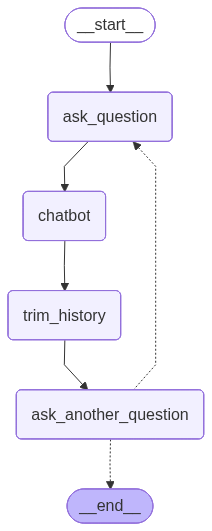

In [12]:
def trim_history(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING trim_history:")
    keep_last_n = 5
    if len(state["messages"]) > keep_last_n:
        to_remove = [RemoveMessage(id=msg.id) for msg in state["messages"][:-keep_last_n]]
        print(f"  Pruning {len(to_remove)} message(s), keeping last {keep_last_n}.")
        return MessagesState(messages=to_remove)
    return MessagesState(messages=[])

graph5 = StateGraph(MessagesState)
graph5.add_node("ask_question", ask_question)
graph5.add_node("chatbot", chatbot)
graph5.add_node("trim_history", trim_history)
graph5.add_node("ask_another_question", ask_another_question)
graph5.add_edge(START, "ask_question")
graph5.add_edge("ask_question", "chatbot")
graph5.add_edge("chatbot", "trim_history")
graph5.add_edge("trim_history", "ask_another_question")
graph5.add_conditional_edges(source="ask_another_question", path=routing_function)

graph5_compiled = graph5.compile()
graph5_compiled

### Test

In [13]:
graph5_compiled.invoke(MessagesState(messages=[]))


-------> ENTERING ask_question:
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests

-------> ENTERING trim_history:

-------> ENTERING ask_another_question:
================================== Ai Message ==================================

What is your question?
===================

 yes



-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message ==============

 Name a few tourist spots to visit in the country



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message ===================

 no


{'messages': [AIMessage(content='Would you like to ask one more question (yes/no)?', additional_kwargs={}, response_metadata={}, id='266dbd49-c92a-4270-8abb-5b8d45b7d434', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='5a1570f4-303b-4b9a-9dc3-f37213581511'),
  AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='1448586d-a975-43fc-92eb-24eee112c9b4', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Name a few tourist spots to visit in the country', additional_kwargs={}, response_metadata={}, id='f637a8d5-5bfd-4976-afc1-3b2d0466c3e8'),
  AIMessage(content="The Philippines is known for its stunning natural beauty and diverse cultural heritage, offering a wide range of tourist attractions. Here are a few notable spots to visit:\n\n1. **Boracay Island**: Famous for its white sandy beaches and vibrant nightlife, Boracay is a popular destination for beach lovers and wate

---
## 6 · Deferred Pruning: Trim on Loop-Back

Section 5 pruned history **proactively** — after every chatbot turn, regardless of whether the conversation continued. This section shows a subtly different strategy: pruning is **deferred** to the routing decision.

When the user answers "yes", the router sends to `trim_messages` first; `trim_messages` prunes and then jumps back to `ask_question`, entering the next turn with a clean context window. When the user answers "no", the graph ends — no unnecessary pruning on the final turn.

The topology change is small but meaningful:

| | Section 5 | Section 6 |
|---|---|---|
| Pruning trigger | Every turn, unconditionally | Only when looping back ("yes") |
| Pruning position | Between `chatbot` → `ask_another_question` | Between routing → `ask_question` |
| Final-turn overhead | Prunes then immediately ends | Skips pruning entirely |

### Routing Function

The routing function now returns `"trim_messages"` instead of `"ask_question"` for the "yes" branch — delegating the loop-back edge to the pruning node.

### Pruning Node

`trim_messages` is unchanged in logic — keep the last 5 — but its **position in the graph** gives it a different role: it acts as a gateway into the next loop iteration rather than a post-processing step.

### Graph

The key topological difference: `trim_messages → ask_question` replaces the earlier `chatbot → trim_history → ask_another_question` chain. `trim_messages` now owns the loop-back edge.

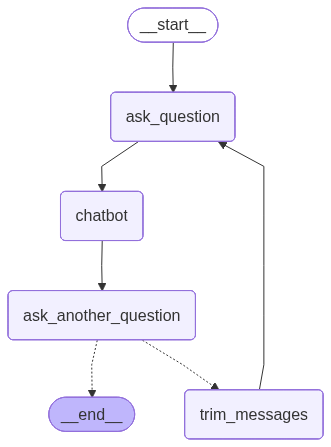

In [14]:
def routing_function_v2(state: MessagesState) -> Literal["trim_messages", "__end__"]:
    return "trim_messages" if state["messages"][-1].content == "yes" else "__end__"

def trim_messages(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING trim_messages:")
    to_remove = [RemoveMessage(id=msg.id) for msg in state["messages"][:-5]]
    print(f"  Pruning {len(to_remove)} message(s), keeping last 5.")
    return MessagesState(messages=to_remove)

graph6 = StateGraph(MessagesState)
graph6.add_node("ask_question", ask_question)
graph6.add_node("chatbot", chatbot)
graph6.add_node("ask_another_question", ask_another_question)
graph6.add_node("trim_messages", trim_messages)
graph6.add_edge(START, "ask_question")
graph6.add_edge("ask_question", "chatbot")
graph6.add_edge("chatbot", "ask_another_question")
graph6.add_conditional_edges(source="ask_another_question", path=routing_function_v2)
graph6.add_edge("trim_messages", "ask_question")

graph6_compiled = graph6.compile()
graph6_compiled

### Test

In [15]:
graph6_compiled.invoke(MessagesState(messages=[]))


-------> ENTERING ask_question:
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests

-------> ENTERING ask_another_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =====

 yes



-------> ENTERING trim_messages:
  Pruning 0 message(s), keeping last 5.

-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more questi

 What is the best beach to visit in the country?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
The Philippines has a diverse range of landscapes, including mountains, rainforests
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message ===================

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='5b4cb528-aa47-4537-b2c7-52d13173a37e', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Describe the Philippines', additional_kwargs={}, response_metadata={}, id='12fbb7a7-2d11-489d-9a9f-f2ac9c3e94ff'),
  AIMessage(content='The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.\n\n**Geography and Climate:**\nThe Philippines has a diverse range of landscapes, including mountains, rainforests', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 19, 'total_tokens': 119, 'completion_tokens_details': {'

---
## 7 · Summarizing Messages: Long-Term Memory with Compression

Trimming messages (Sections 5–6) keeps the context window bounded, but it **discards information** — once a message is deleted, it's gone. **Summarization** offers a smarter trade-off: compress the conversation history into a rolling summary stored in a dedicated `summary` field, then delete the raw messages. The LLM always has a compact but semantically rich picture of what has been discussed.

This section builds on `MessagesState` by subclassing it to add a `summary` key, then introduces a `summarize_and_delete_messages` node that rewrites the summary and clears the message buffer — so the graph stays within context limits without losing conversational continuity.

### Additional Import

`SystemMessage` — added to the global imports above — is used here to inject the rolling summary as a system-level instruction before each LLM call. Everything else (`MessagesState`, `RemoveMessage`, `Literal`) was already available.

### Define the State

`MessagesState` already handles the `messages` field with the `add_messages` reducer. Subclassing it adds a single extra key — `summary: str` — which stores the rolling compressed summary of past conversation. Keeping it separate from `messages` makes it easy to inject as a `SystemMessage` and update independently without touching the message reducer.

In [16]:
class State7(MessagesState):
    summary: str

# On the first turn there is no summary yet — get() returns "" (falsy),
# so chatbot knows to skip summary injection.
test_state = State7()
bool(test_state.get("summary", ""))

False

### Nodes

`ask_question` and `ask_another_question` follow the same pattern as previous sections. The meaningful change is `chatbot`: it now reads `state["summary"]` and injects it as a `SystemMessage` before calling the LLM, so prior context is always available even after the raw messages have been deleted. `summarize_and_delete_messages` is the new node that compresses history into a rolling summary and clears the message buffer.

In [17]:
def ask_question(state: State7) -> State7:
    print(f"\n-------> ENTERING ask_question:")
    for msg in state["messages"]:
        msg.pretty_print()
    question = "What is your question?"
    print(question)
    return State7(messages=[AIMessage(question), HumanMessage(input())])

def chatbot(state: State7) -> State7:
    print(f"\n-------> ENTERING chatbot:")
    for msg in state["messages"]:
        msg.pretty_print()
    summary = state.get("summary", "")
    system_message = SystemMessage(
        f"Here's a summary of the conversation so far:\n{summary}\n\nKeep this in mind as you answer."
        if summary else "You are a helpful assistant."
    )
    response = chat.invoke([system_message] + list(state["messages"]))
    response.pretty_print()
    return State7(messages=[response])

def ask_another_question(state: State7) -> State7:
    print(f"\n-------> ENTERING ask_another_question:")
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    return State7(messages=[AIMessage(question), HumanMessage(input())])

def summarize_and_delete_messages(state: State7) -> State7:
    print(f"\n-------> ENTERING summarize_and_delete_messages:")
    transcript = "\n\n".join(f"{msg.type}: {msg.content}" for msg in state["messages"])
    prompt = (
        "Update the ongoing summary by incorporating the new conversation below.\n"
        "Build upon the previous summary rather than repeating it.\n\n"
        f"Previous Summary:\n{state.get('summary', '(none)')}\n\n"
        f"New Conversation:\n{transcript}"
    )
    summary = chat.invoke([HumanMessage(prompt)])
    remove = [RemoveMessage(id=msg.id) for msg in state["messages"]]
    return State7(messages=remove, summary=summary.content)

### Define the Routing Function

### Define the Graph

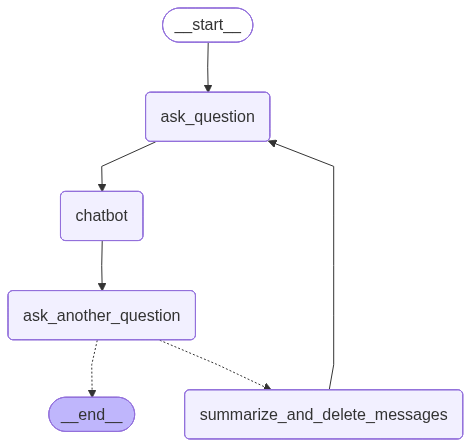

In [18]:
def routing_function(state: State7) -> Literal["summarize_and_delete_messages", "__end__"]:
    return "summarize_and_delete_messages" if state["messages"][-1].content == "yes" else "__end__"

graph7 = StateGraph(State7)
graph7.add_node("ask_question", ask_question)
graph7.add_node("chatbot", chatbot)
graph7.add_node("ask_another_question", ask_another_question)
graph7.add_node("summarize_and_delete_messages", summarize_and_delete_messages)
graph7.add_edge(START, "ask_question")
graph7.add_edge("ask_question", "chatbot")
graph7.add_edge("chatbot", "ask_another_question")
graph7.add_conditional_edges("ask_another_question", routing_function)
graph7.add_edge("summarize_and_delete_messages", "ask_question")

graph7_compiled = graph7.compile()
graph7_compiled

### Test

In [19]:
graph7_compiled.invoke(State7(messages=[]))


-------> ENTERING ask_question:
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, situated in the western Pacific Ocean. It consists of approximately 7,641 islands, which are broadly categorized into three main geographical divisions: Luzon, Visayas, and Mindanao. The capital city is Manila, while the largest city in terms of population is Quezon City, both of which are part of the National Capital Region (NCR).

### Geography
- **Luzon**: The largest and most populous island,

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 yes



-------> ENTERING summarize_and_delete_messages:

-------> ENTERING ask_question:
What is your question?


 What is the best city in the country?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What is the best city in the country?
================================== Ai Message ==================================

Determining the "best" city in the Philippines can be subjective and depends on what criteria you're considering, such as lifestyle, economic opportunities, culture, or natural beauty. Here are a few cities that are often highlighted for different reasons:

1. **Manila**: As the capital city, Manila is the political and cultural heart of the country, offering a rich history and vibrant urban life.

2. **Quezon City**: The largest city by population, it is a major hub for education

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='868a46a0-4e1b-4c3f-a849-0bbacd714867', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What is the best city in the country?', additional_kwargs={}, response_metadata={}, id='4fa9bf62-c893-4210-847a-8284df5231ca'),
  AIMessage(content='Determining the "best" city in the Philippines can be subjective and depends on what criteria you\'re considering, such as lifestyle, economic opportunities, culture, or natural beauty. Here are a few cities that are often highlighted for different reasons:\n\n1. **Manila**: As the capital city, Manila is the political and cultural heart of the country, offering a rich history and vibrant urban life.\n\n2. **Quezon City**: The largest city by population, it is a major hub for education', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 147, 'total_tokens': 247, 'completi

---
## 8 · Short-Term Memory with `InMemorySaver`

All graphs in Sections 1–7 were stateless across *invocations*: each call to `.invoke()` started fresh. **Checkpointers** fix this by writing state snapshots after every node, keyed by a `thread_id`. Re-invoking with the same `thread_id` resumes the conversation exactly where it left off — as long as the process is running.

`InMemorySaver` is the simplest checkpointer: it stores snapshots in a Python dict. It is perfect for development, testing, and single-session use cases where persistence across process restarts is not needed.

### Key changes from Section 7

- **`checkpointer = InMemorySaver()`** — created once, passed to `.compile()`.
- **`config = {"configurable": {"thread_id": "1"}}`** — every `.invoke()` call must pass a config dict that specifies the thread. Different thread IDs maintain completely separate conversation histories.
- The graph topology is unchanged from Section 7 (summarisation-on-loop-back).

### Multiple threads

Because state is keyed by `thread_id`, you can run independent conversations in parallel by simply using different IDs — `config1` and `config2` below demonstrate two threads sharing the same compiled graph without interfering with each other.

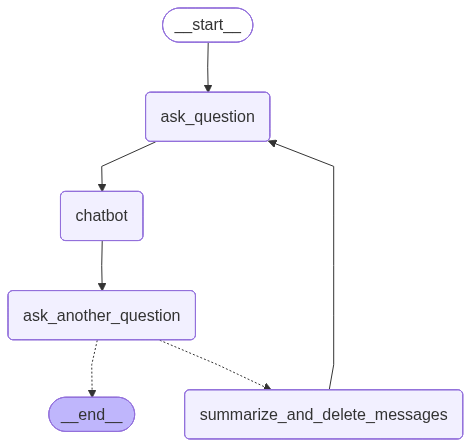

In [20]:
# Re-use State and nodes from Section 7 (State7, ask_question, chatbot,
# ask_another_question, summarize_and_delete_messages, routing_function)

graph8 = StateGraph(State7)
graph8.add_node("ask_question", ask_question)
graph8.add_node("chatbot", chatbot)
graph8.add_node("ask_another_question", ask_another_question)
graph8.add_node("summarize_and_delete_messages", summarize_and_delete_messages)
graph8.add_edge(START, "ask_question")
graph8.add_edge("ask_question", "chatbot")
graph8.add_edge("chatbot", "ask_another_question")
graph8.add_conditional_edges("ask_another_question", routing_function)
graph8.add_edge("summarize_and_delete_messages", "ask_question")

checkpointer8 = InMemorySaver()
graph8_compiled = graph8.compile(checkpointer8)
graph8_compiled

### Test — Thread 1

In [21]:
config1 = {"configurable": {"thread_id": "1"}}
config2 = {"configurable": {"thread_id": "2"}}

graph8_compiled.invoke(State7(messages=[]), config1)


-------> ENTERING ask_question:
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is bordered by the South China Sea to the west, the Philippine Sea to the east, and the Celebes Sea to the south. The country is divided into three main geographical divisions: Luzon, Visayas, and Mindanao.

**Geography and Climate:**
- The Philippines has a diverse range of landscapes, including mountains, rainfore

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 yes



-------> ENTERING summarize_and_delete_messages:

-------> ENTERING ask_question:
What is your question?


 What are the top food delicacies in the country?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What are the top food delicacies in the country?
================================== Ai Message ==================================

The Philippines is known for its rich and diverse culinary heritage, influenced by various cultures over the centuries. Here are some of the top food delicacies you should try:

1. **Adobo**: Often considered the unofficial national dish, adobo is a savory stew made with chicken or pork marinated in vinegar, soy sauce, garlic, and spices, then simmered until tender.

2. **Sinigang**: A sour soup typically made with pork, shrimp, or fish, and flavored

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='552aacd4-252c-4650-ab97-09dad37a88fb', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What are the top food delicacies in the country?', additional_kwargs={}, response_metadata={}, id='4acff18e-9ad8-4f48-8b18-7e2059def7da'),
  AIMessage(content='The Philippines is known for its rich and diverse culinary heritage, influenced by various cultures over the centuries. Here are some of the top food delicacies you should try:\n\n1. **Adobo**: Often considered the unofficial national dish, adobo is a savory stew made with chicken or pork marinated in vinegar, soy sauce, garlic, and spices, then simmered until tender.\n\n2. **Sinigang**: A sour soup typically made with pork, shrimp, or fish, and flavored', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 149, 'total_tokens': 249, 'completion_tokens_details': {

---
## 9 · The `StateSnapshot` Class

Every time a checkpointer writes state it creates a **`StateSnapshot`** — a frozen record of the graph at a particular step. `get_state_history(config)` returns the full list of snapshots for a thread, oldest first, so you can replay or audit an entire conversation.

Each snapshot exposes three key fields:

| Field | Description |
|---|---|
| `values` | The state dict at that step (`messages`, `summary`, …) |
| `next` | The node(s) that will run from this snapshot if resumed |
| `metadata["step"]` | A monotonically increasing integer — step 0 is before any node runs |

Iterating the history in reverse (oldest → newest) gives you a clean transcript of the conversation, including every intermediate state the graph passed through.


In [22]:
# Retrieve all snapshots for thread 1 (must have run Section 8 first)
graph_states = [i for i in graph8_compiled.get_state_history(config1)]

# Print oldest-to-newest
for i in graph_states[::-1]:
    print(f"""
Messages: {i.values["messages"]}
Summary:  {i.values.get("summary", "")}
Next:     {i.next}
Step:     {i.metadata["step"]}""")


Messages: []
Summary:  
Next:     ('__start__',)
Step:     -1

Messages: []
Summary:  
Next:     ('ask_question',)
Step:     0

Messages: [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='8f22695f-3cc9-4509-b0c6-02e0067f3a09', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Describe the Philippines', additional_kwargs={}, response_metadata={}, id='de995e5d-4c80-4f28-a030-2741c6786e43')]
Summary:  
Next:     ('chatbot',)
Step:     1

Messages: [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='8f22695f-3cc9-4509-b0c6-02e0067f3a09', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Describe the Philippines', additional_kwargs={}, response_metadata={}, id='de995e5d-4c80-4f28-a030-2741c6786e43'), AIMessage(content='The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641 islands. It is situated in the western Pacific Ocean and is borde

---
## 10 · Long-Term Memory with `SqliteSaver`

`InMemorySaver` forgets everything when the process exits. **`SqliteSaver`** writes snapshots to a SQLite database file, so conversations survive restarts — giving the agent genuine long-term memory.

### Swap in three lines

```python
con = sqlite3.connect(db_path, check_same_thread=False)
checkpointer = SqliteSaver(con)
graph_compiled = graph.compile(checkpointer)
```

Everything else — state, nodes, edges, thread IDs — is identical to Section 8. The `check_same_thread=False` flag is required because LangGraph may access the connection from different threads internally.

### Choosing a database path

Set `db_path` to any writable location. The example below uses a path relative to the notebook's working directory so the code is portable across operating systems — replace it with an absolute path if you prefer.


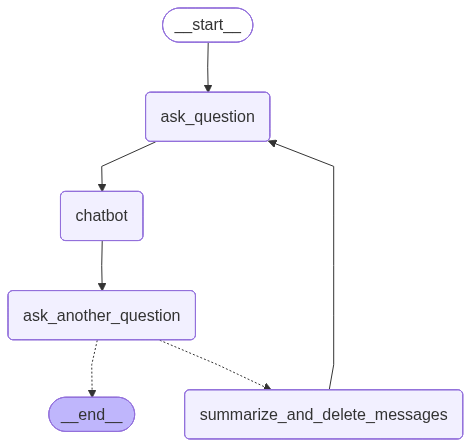

In [23]:
db_path = "langgraph.db"  # saved in the notebook's working directory
con = sqlite3.connect(database=db_path, check_same_thread=False)

checkpointer10 = SqliteSaver(con)

graph10 = StateGraph(State7)
graph10.add_node("ask_question", ask_question)
graph10.add_node("chatbot", chatbot)
graph10.add_node("ask_another_question", ask_another_question)
graph10.add_node("summarize_and_delete_messages", summarize_and_delete_messages)
graph10.add_edge(START, "ask_question")
graph10.add_edge("ask_question", "chatbot")
graph10.add_edge("chatbot", "ask_another_question")
graph10.add_conditional_edges("ask_another_question", routing_function)
graph10.add_edge("summarize_and_delete_messages", "ask_question")

graph10_compiled = graph10.compile(checkpointer10)
graph10_compiled

### Test

Restart the kernel and re-run from Setup through this cell — the conversation history for `thread_id: "1"` will be restored from `langgraph.db`.

In [24]:
config10 = {"configurable": {"thread_id": "1"}}
graph10_compiled.invoke(State7(messages=[]), config10)


-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What is the country mentioned earlier?
================================== Ai Message ==================================

The country mentioned earlier is the Philippines.
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message =================================

no
What is your question?


 Describe the Philippines



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What is the country mentioned earlier?
================================== Ai Message ==================================

The country mentioned earlier is the Philippines.
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message =================================

no
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Describe the Philippines
================================== Ai Message ==================================

The Philippines is an archipelagic country located in Southeast Asia, consisting of approximately 7,641

 yes



-------> ENTERING summarize_and_delete_messages:

-------> ENTERING ask_question:
What is your question?


...


-------> ENTERING summarize_and_delete_messages:

-------> ENTERING ask_question:
What is your question?


 What country is mentioned earlier?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What country is mentioned earlier?
================================== Ai Message ==================================

The country mentioned earlier is the Philippines.

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='986ec43c-03cd-469b-ba24-b5a45ac3d936', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What country is mentioned earlier?', additional_kwargs={}, response_metadata={}, id='26f7e89c-e1ae-4c4b-b089-e5d15f00ff0d'),
  AIMessage(content='The country mentioned earlier is the Philippines.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 144, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_4070054e71', 'id': 'chatcmpl-Dg311wO3mLQwDoI3ZMiFlnXWjpyND', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2f85-83e2-7b